# 03 – HAR-RV model

Estimate a one-day-ahead HAR-RV model and compare it with a simple persistence benchmark.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv(
    "../data/spy_daily_realized_volatility.csv",
    parse_dates=["date"],
)

df["rv_daily"] = df["log_realized_variance"]
df["rv_weekly"] = df["log_realized_variance"].rolling(5).mean()
df["rv_monthly"] = df["log_realized_variance"].rolling(22).mean()
df["target"] = df["log_realized_variance"].shift(-1)
df["target_date"] = df["date"].shift(-1)

har_data = df[
    ["date", "target_date", "rv_daily", "rv_weekly", "rv_monthly", "target"]
].dropna().copy()

har_data.head()

,date,target_date,rv_daily,rv_weekly,rv_monthly,target
21,2024-11-04,2024-11-05,-10.317511,-10.251208,-10.691808,-10.397592
22,2024-11-05,2024-11-06,-10.397592,-10.226694,-10.714495,-10.270716
23,2024-11-06,2024-11-07,-10.270716,-10.135939,-10.695987,-11.139952
24,2024-11-07,2024-11-08,-11.139952,-10.410438,-10.701170,-11.595449
25,2024-11-08,2024-11-11,-11.595449,-10.744244,-10.722783,-11.377216


## Train/test split

In [3]:
split = int(len(har_data) * 0.8)

train = har_data.iloc[:split].copy()
test = har_data.iloc[split:].copy()

print("Training observations:", len(train))
print("Test observations:", len(test))
print("Training period:", train["date"].min(), "to", train["date"].max())
print("Test period:", test["target_date"].min(), "to", test["target_date"].max())

Training observations: 376
Test observations: 95
Training period: 2024-11-04 00:00:00 to 2026-05-13 00:00:00
Test period: 2026-05-15 00:00:00 to 2026-09-30 00:00:00


## Estimate HAR-RV

In [4]:
features = ["rv_daily", "rv_weekly", "rv_monthly"]

X_train = sm.add_constant(train[features])
y_train = train["target"]

har_model = sm.OLS(y_train, X_train).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 5},
)

har_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     74.29
Date:                Sun, 04 Oct 2026   Prob (F-statistic):           1.14e-37
Time:                        13:19:23   Log-Likelihood:                -396.64
No. Observations:                 376   AIC:                             801.3
Df Residuals:                     372   BIC:                             817.0
Df Model:                           3                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4438      0.673     -2.144      0.032      -2.764      -0.124
rv_daily       0.5133      0.069      7.477      0.000       0.379       0.648
rv_weekly      0.2327      0.073      3.184      0.001       0.089       0.376
rv_monthly     0.1138      0.066      1.728      0.084      -0.015       0.243
==============================================================================
Omnibus:                       17.808   Durbin-Watson:                   2.017
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               23.971
Skew:                           0.392   Prob(JB):                     6.23e-06
Kurtosis:                       3.957   Cond. No.                         292.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 5 lags and without small sample correction
"""

In [5]:
X_test = sm.add_constant(test[features])
test["predicted_log_rv"] = har_model.predict(X_test)
test["naive_prediction"] = test["rv_daily"]

## Out-of-sample evaluation

In [6]:
def qlike_loss(actual, forecast):
    ratio = actual / forecast
    return ratio - np.log(ratio) - 1


test["actual_rv"] = np.exp(test["target"])
test["har_rv_forecast"] = np.exp(test["predicted_log_rv"])
test["naive_rv_forecast"] = np.exp(test["naive_prediction"])

har_mae = mean_absolute_error(test["target"], test["predicted_log_rv"])
har_rmse = np.sqrt(mean_squared_error(test["target"], test["predicted_log_rv"]))
har_qlike = qlike_loss(test["actual_rv"], test["har_rv_forecast"]).mean()

naive_mae = mean_absolute_error(test["target"], test["naive_prediction"])
naive_rmse = np.sqrt(mean_squared_error(test["target"], test["naive_prediction"]))
naive_qlike = qlike_loss(test["actual_rv"], test["naive_rv_forecast"]).mean()

pd.DataFrame({
    "Model": ["HAR-RV", "Naive"],
    "MAE": [har_mae, naive_mae],
    "RMSE": [har_rmse, naive_rmse],
    "QLIKE": [har_qlike, naive_qlike],
})

,Model,MAE,RMSE,QLIKE
0,HAR-RV,0.474115,0.643004,0.236613
1,Naive,0.533653,0.723066,0.302232


In [7]:
test["har_qlike_loss"] = qlike_loss(test["actual_rv"], test["har_rv_forecast"])
test["naive_qlike_loss"] = qlike_loss(test["actual_rv"], test["naive_rv_forecast"])

loss_diff = test["naive_qlike_loss"] - test["har_qlike_loss"]

loss_test = sm.OLS(loss_diff, np.ones(len(loss_diff))).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 5},
)

print("Mean loss difference:", round(loss_test.params.iloc[0], 6))
print("P-value:", round(loss_test.pvalues.iloc[0], 6))

Mean loss difference: 0.065619
P-value: 0.049387


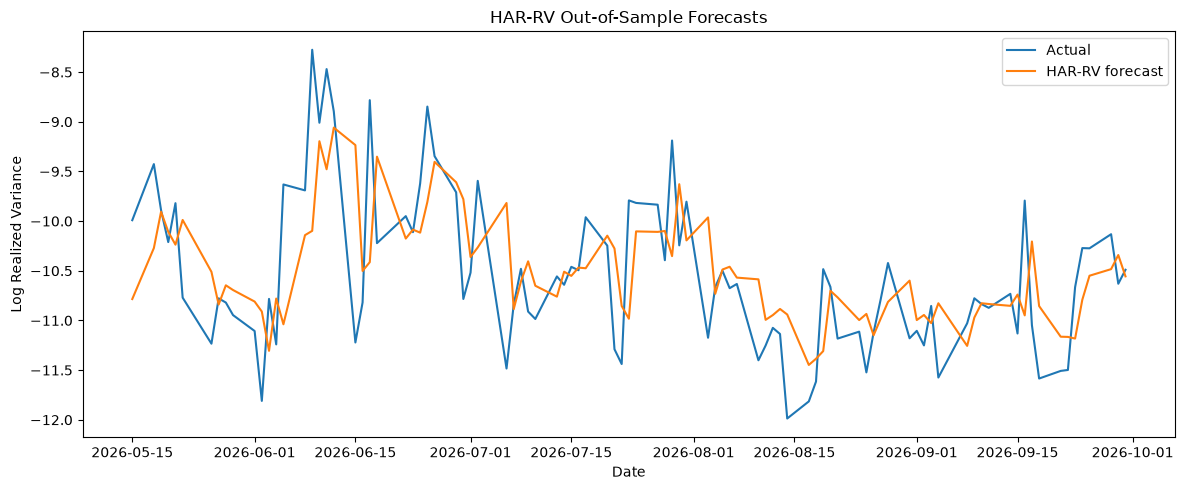

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(test["target_date"], test["target"], label="Actual")
plt.plot(test["target_date"], test["predicted_log_rv"], label="HAR-RV forecast")
plt.title("HAR-RV Out-of-Sample Forecasts")
plt.xlabel("Date")
plt.ylabel("Log Realized Variance")
plt.legend()
plt.tight_layout()
plt.show()

## Save results

In [9]:
results = pd.DataFrame({
    "Model": ["HAR-RV", "Naive"],
    "MAE": [har_mae, naive_mae],
    "RMSE": [har_rmse, naive_rmse],
    "QLIKE": [har_qlike, naive_qlike],
})

results.to_csv("../results/har_rv_results.csv", index=False)

test[[
    "target_date",
    "target",
    "predicted_log_rv",
    "actual_rv",
    "har_rv_forecast",
    "naive_rv_forecast",
]].to_csv("../results/har_rv_forecasts.csv", index=False)